# Resample a diagnostic onto the GWL grid

Map an **annual** series from calendar years to **global warming level (GWL)** so
models can be compared at the same warming.

Prerequisite: `pip install -e .` from the repo root. No TIPMIP files needed — we
use a bundled mapping and a synthetic diagnostic.


Import libraries and `tipmip_gwl` helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from tipmip_gwl import load_mapping, list_models, resample_to_gwl

Eight Tier-1 models ship in mapping version v1.


In [2]:
list_models()

['ACCESS-ESM1-5',
 'EC-Earth3-ESM-1',
 'GFDL-ESM2M',
 'GISS-E2-1-G-CC2',
 'IPSL-CM6-ESMCO2',
 'MIROC-ES2L',
 'NorESM2-LM',
 'UKESM1-2-LL']

Load the ramp-up mapping for one model.


In [4]:
MODEL = "GFDL-ESM2M"
mp = load_mapping(MODEL)

Build a toy diagnostic on calendar years.


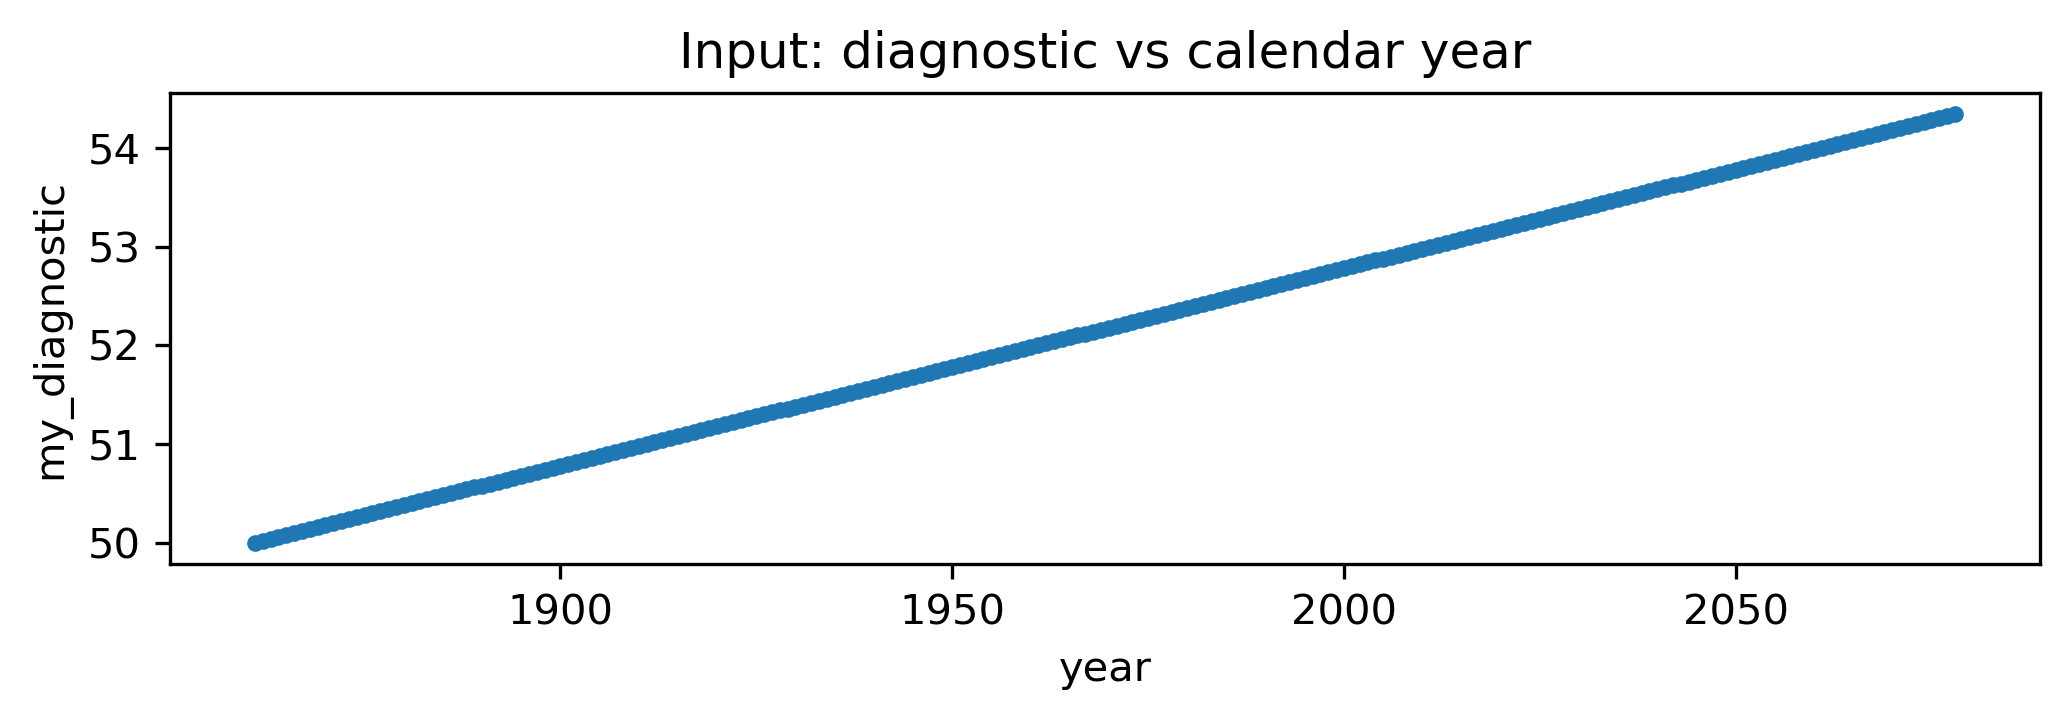

In [21]:
years = mp["year"].values

diagnostic = xr.DataArray(
    50 + 0.02 * (years - years[0]),
    dims="year",
    coords={"year": years},
    name="my_diagnostic",
)

fig, ax = plt.subplots(figsize=(7, 2.5), dpi=300)
diagnostic.plot(ax=ax, marker=".")
plt.title("Input: diagnostic vs calendar year")
plt.tight_layout()

Resample onto the shared 0.02 °C GWL grid.


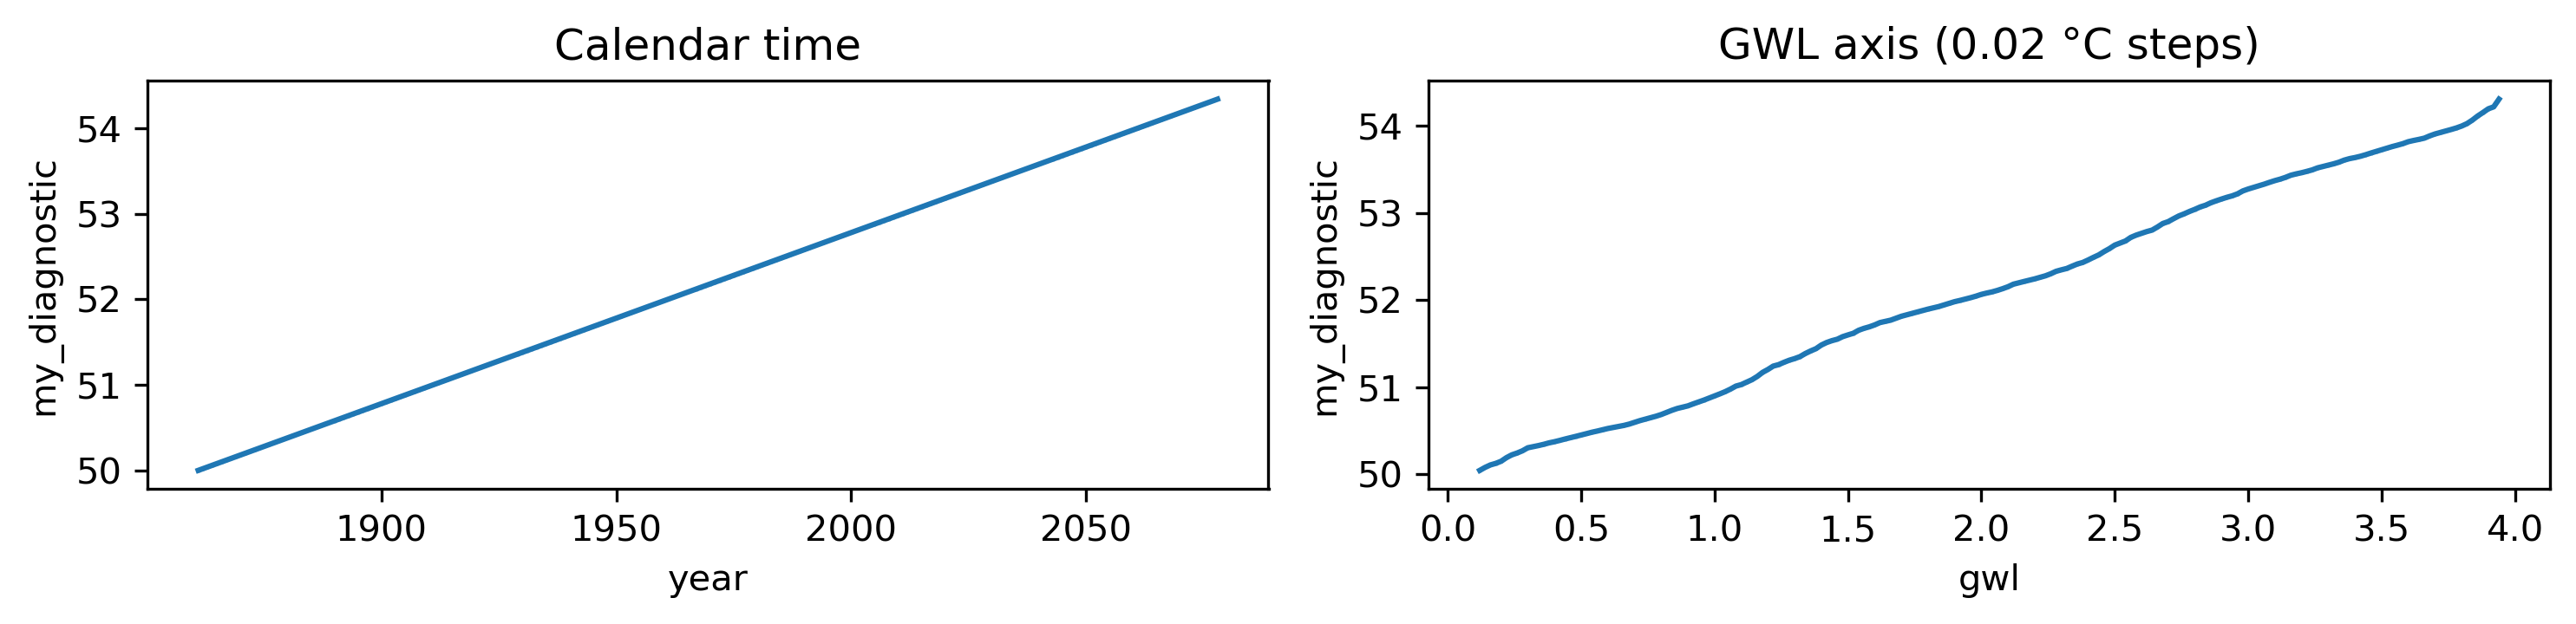

In [69]:
on_gwl = resample_to_gwl(mp, diagnostic)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5), dpi=300)
diagnostic.plot(ax=axes[0], marker=".", ms=0.1)
axes[0].set_title("Calendar time")
on_gwl.plot(ax=axes[1], marker=".", ms=0.1)
axes[1].set_title("GWL axis (0.02 °C steps)")
plt.tight_layout()

Comparing relabelled with resampled


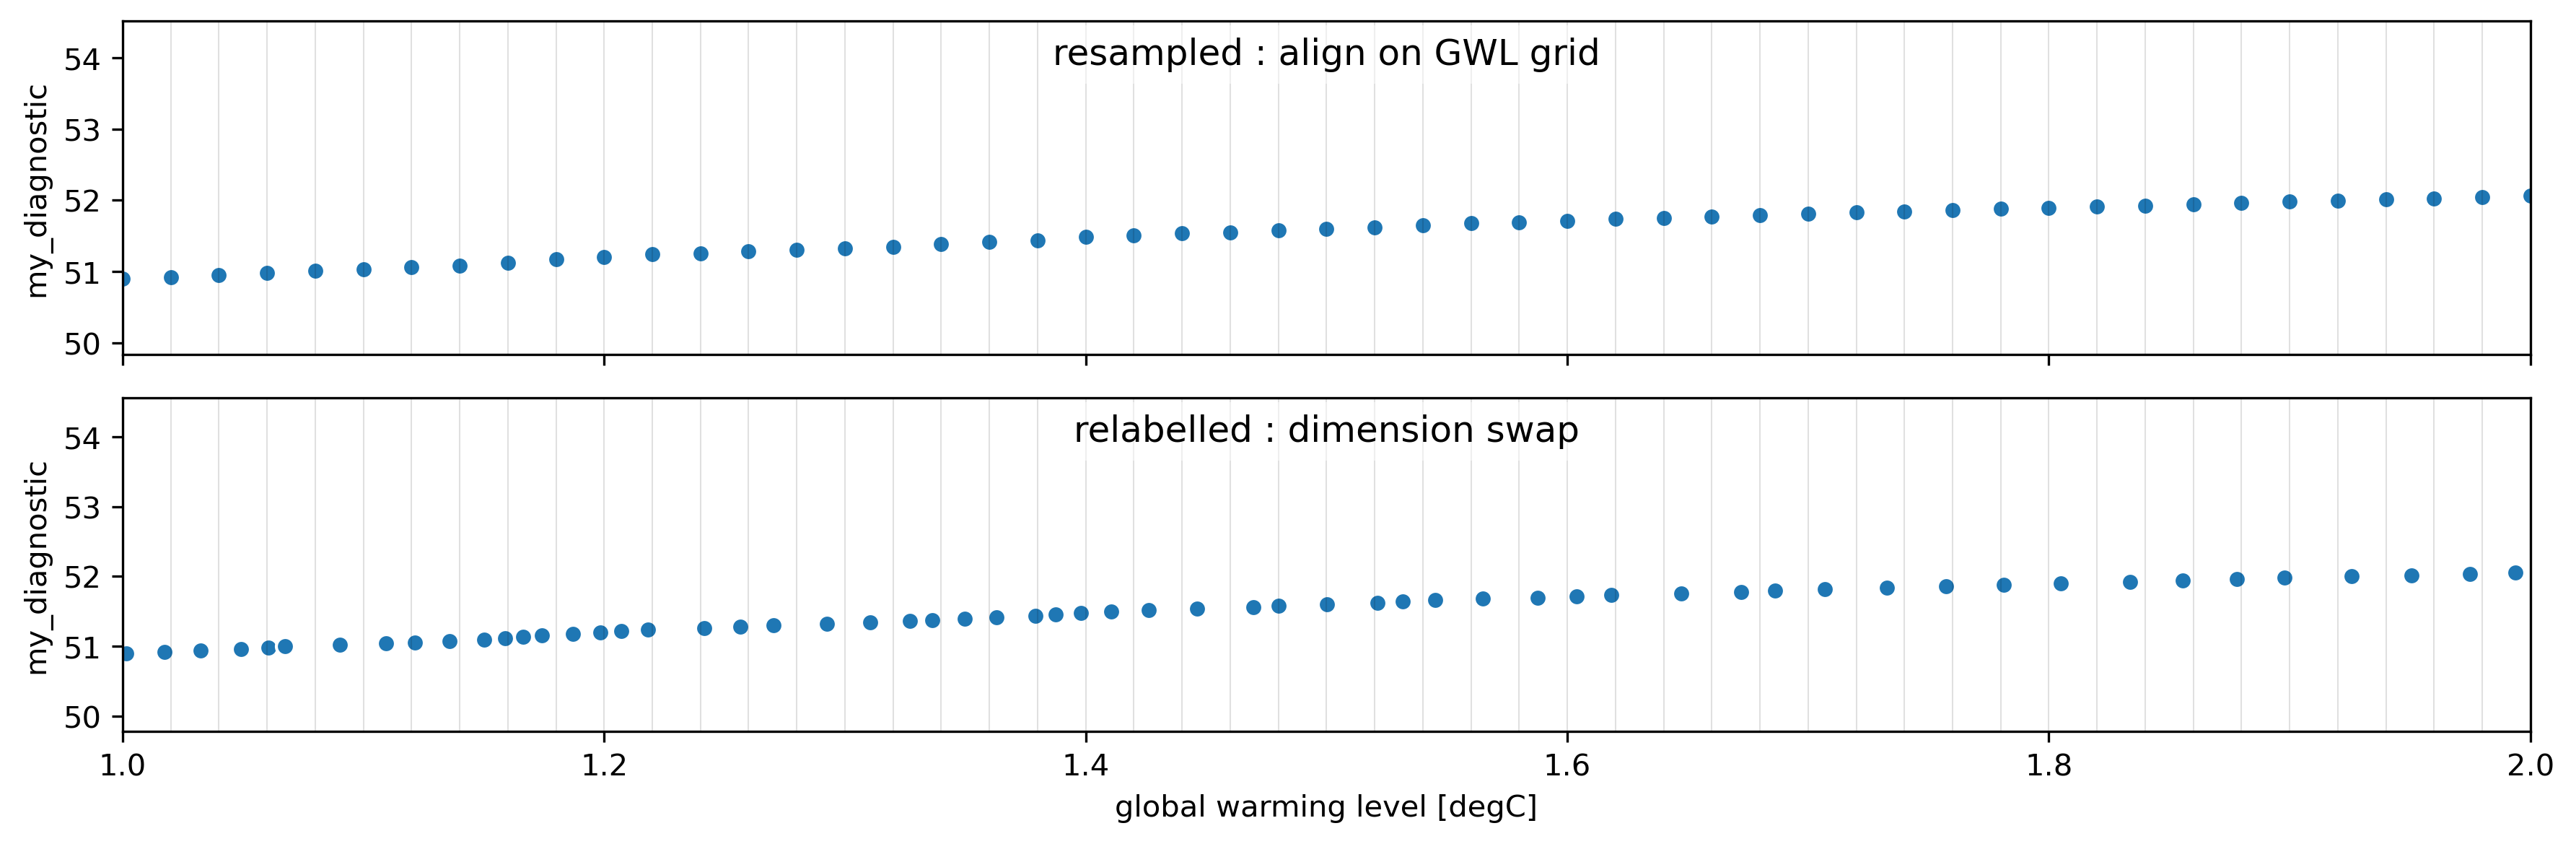

In [68]:
from tipmip_gwl import relabel_to_gwl, resample_to_gwl

# Remapping
resampled = resample_to_gwl(mp, diagnostic)
relabelled = relabel_to_gwl(mp, diagnostic)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 4), dpi=300, sharex=True)
resampled.plot.scatter(x="gwl", y="my_diagnostic", ax=axes[0])
axes[0].set_xlim(0, 1)
axes[0].text(
    0.5,
    0.9,
    "resampled : align on GWL grid",
    ha="center",
    va="center",
    transform=axes[0].transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"),
)
axes[0].set_xlabel("")
relabelled.plot.scatter(x="gwl", y="my_diagnostic", ax=axes[1])
axes[1].set_xlim(1, 2)
axes[1].text(
    0.5,
    0.9,
    "relabelled : dimension swap",
    ha="center",
    va="center",
    transform=axes[1].transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"),
)
for ax in axes:
    for x in np.arange(1, 2, 0.02):
        ax.axvline(x, color="k", lw=0.5, alpha=0.12)
plt.tight_layout()